# Acompanhamento 1: Análise Exploratória e Limpeza de Dados
**Projeto:** <h2>Competição de Machine Learning - Previsão de Preços de Imóveis</h2>
**Equipe:**
* Kalil Smith Pinto Palheta - 2223857
* Gabriel Abreu Cunha De Alencar - 2315097
* Igor Gomes Ximenes - 2217665

## 1. Importação de Bibliotecas e Carregamento dos Dados

In [39]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
# So usado depois no codigo 
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import mean_squared_error, median_absolute_error, r2_score
from xgboost import XGBRegressor

# Apenas configuração de estilo para os gráficos
sns.set_theme(style="whitegrid")

# Carregamento no base 
df_treino = pd.read_csv('treino.csv')

# Visão inicial do dataset
display(df_treino.head())
print(f"O dataset de treino {df_treino.shape[0]} linhas e {df_treino.shape[1]} colunas.")

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,145000
1,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,178000
2,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal,85000
3,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,175000
4,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,127000


O dataset de treino 1168 linhas e 81 colunas.


## <h3>2. Análise Exploratória da Variável Alvo (`SalePrice`)</h3>
Antes de analisar as variáveis explicativas, precisamos entender o comportamento dos preços das casas.

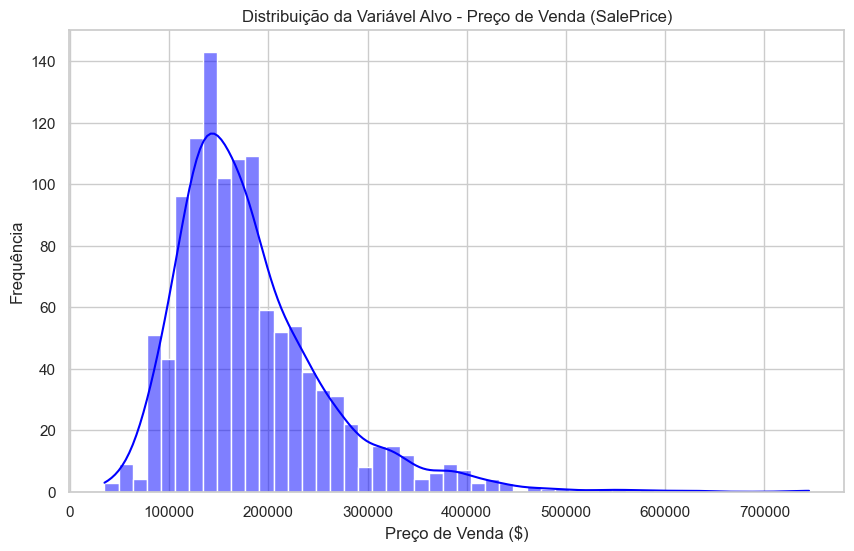

count      1168.000000
mean     181441.541952
std       77263.583862
min       34900.000000
25%      130000.000000
50%      165000.000000
75%      214925.000000
max      745000.000000
Name: SalePrice, dtype: float64


In [40]:
plt.figure(figsize=(10, 6))
sns.histplot(df_treino['SalePrice'], kde=True, color='blue', bins=50)
plt.title('Distribuição da Variável Alvo - Preço de Venda (SalePrice)')
plt.xlabel('Preço de Venda ($)')
plt.ylabel('Frequência')
plt.show()

# Resumo estatístico do SalePrice
print(df_treino['SalePrice'].describe())

# A métrica de avaliação é o RMSLE (logaritmo). 
# Uma assimetria à direita (cauda longa) indica que aplicar log(SalePrice) pode ser benéfico na modelagem.

## <h3>3. Correlação das Variáveis Numéricas</h3>
Vamos identificar quais atributos numéricos possuem maior relação linear com o preço de venda.

Top 10 Variáveis mais correlacionadas com SalePrice:
SalePrice       1.000000
OverallQual     0.801016
GrLivArea       0.723435
GarageCars      0.686763
YearBuilt       0.643216
GarageArea      0.638676
FullBath        0.625567
TotalBsmtSF     0.595014
GarageYrBlt     0.581821
1stFlrSF        0.566305
YearRemodAdd    0.562948
Name: SalePrice, dtype: float64


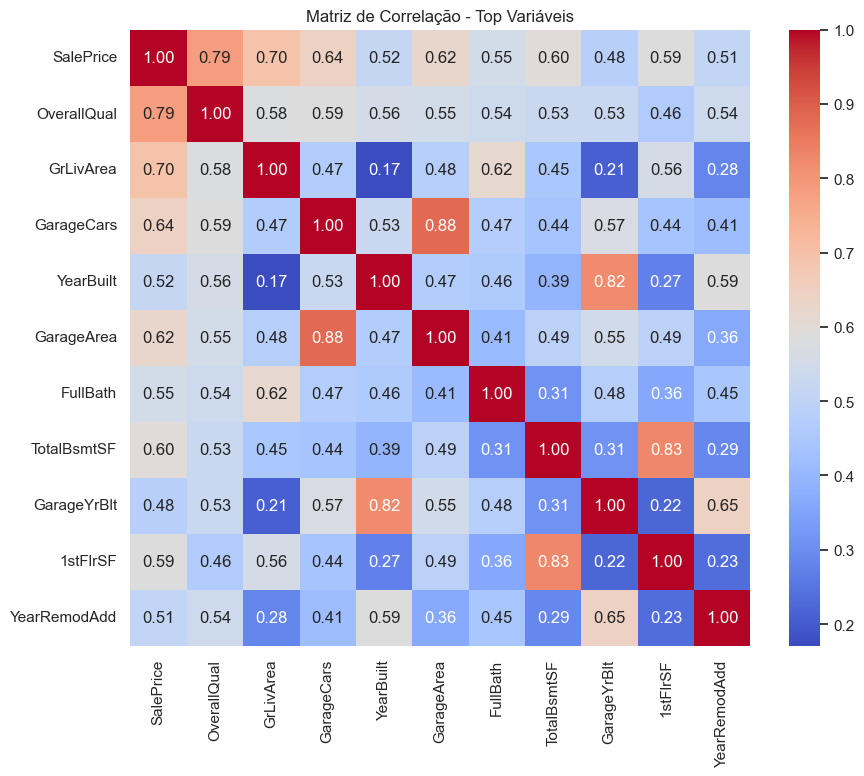

In [41]:
# Selecionar apenas variáveis numéricas
numericas = df_treino.select_dtypes(include=[np.number])

# Calcular a correlação de Spearman (captura relações não-lineares monótonas também)
correlacoes = numericas.corr(method='spearman')['SalePrice'].sort_values(ascending=False)

# Mostrar as 10 variáveis com maior correlação positiva
print("Top 10 Variáveis mais correlacionadas com SalePrice:")
print(correlacoes.head(11)) # Inclui o próprio SalePrice

# Mapa de calor (Heatmap) das variáveis mais importantes
top_features = correlacoes.head(11).index
plt.figure(figsize=(10, 8))
sns.heatmap(df_treino[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação - Top Variáveis')
plt.show()

## <h3>4. Estratégia de Limpeza de Dados (Valores Ausentes e Outliers) </h3>
Para garantir que o modelo consiga generalizar, precisamos mapear os dados nulos e definir nossa estratégia de inputação.

In [55]:
# Mapeamento de dados nulos
nulos = df_treino.isnull().sum()
nulos_percentual = (nulos / len(df_treino)) * 100
df_nulos = pd.DataFrame({'Total Nulos': nulos, 'Percentual (%)': nulos_percentual})
df_nulos = df_nulos[df_nulos['Total Nulos'] > 0].sort_values(by='Percentual (%)', ascending=False)

display(df_nulos)

,Total Nulos,Percentual (%)
PoolQC,1162,99.486301
MiscFeature,1122,96.061644
Alley,1094,93.664384
Fence,935,80.051370
MasVnrType,683,58.476027
FireplaceQu,547,46.832192
LotFrontage,217,18.578767
GarageType,64,5.479452
GarageYrBlt,64,5.479452
GarageFinish,64,5.479452


## <h2>5 Visualização de Outras Variáveis Importantes</h2>

Como identificamos as variáveis numéricas mais correlacionadas com a variável alvo (`SalePrice`), é fundamental entender o comportamento das duas principais: `OverallQual` (Qualidade Geral) e `GrLivArea` (Área Habitável Acima do Solo). A análise visual nos ajuda a confirmar tendências e identificar potenciais *outliers* que podem distorcer o modelo.

C:\Users\kelis\AppData\Local\Temp\ipykernel_2692\1491837537.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='SalePrice', data=df_treino, ax=ax[0], palette='viridis')


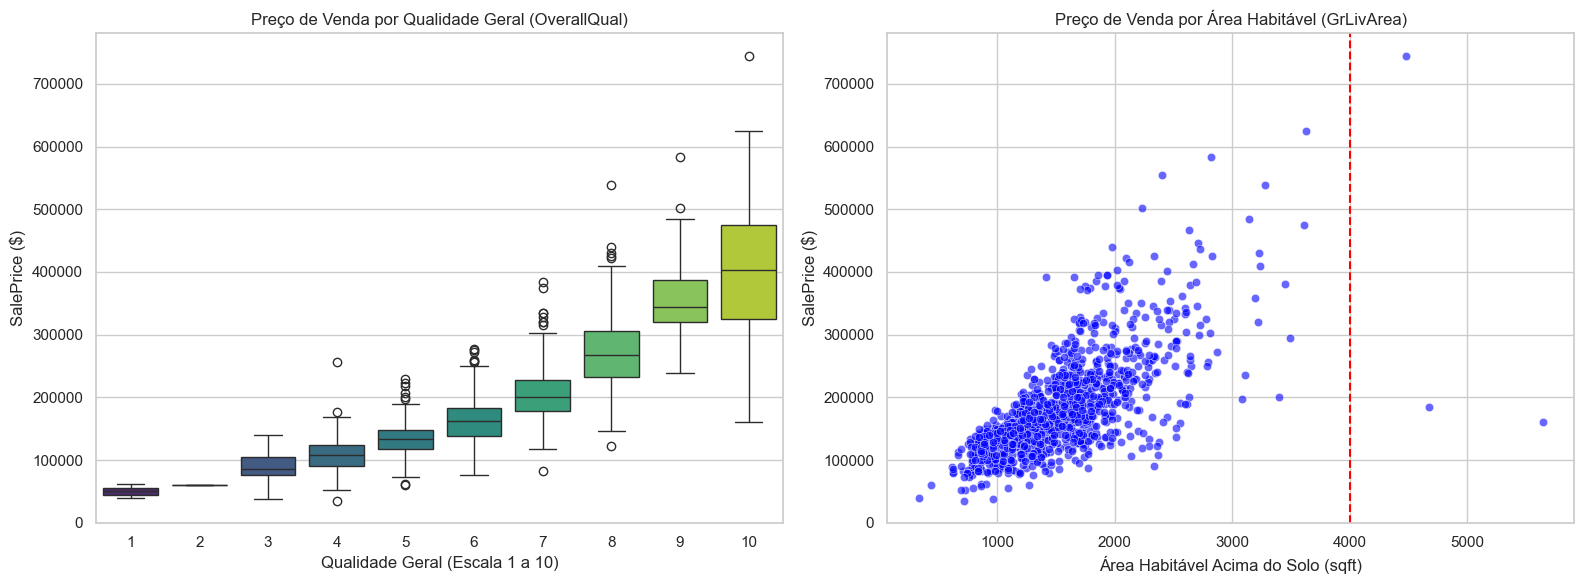

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot de OverallQual vs SalePrice
sns.boxplot(x='OverallQual', y='SalePrice', data=df_treino, ax=ax[0], palette='viridis')
ax[0].set_title('Preço de Venda por Qualidade Geral (OverallQual)')
ax[0].set_xlabel('Qualidade Geral (Escala 1 a 10)')
ax[0].set_ylabel('SalePrice ($)')

# Scatterplot de GrLivArea vs SalePrice
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df_treino, ax=ax[1], alpha=0.6, color='blue')
ax[1].set_title('Preço de Venda por Área Habitável (GrLivArea)')
ax[1].set_xlabel('Área Habitável Acima do Solo (sqft)')
ax[1].set_ylabel('SalePrice ($)')
# Destacando potenciais outliers (imóveis gigantes muito baratos)
plt.axvline(x=4000, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# Observação de Outliers: No gráfico de GrLivArea, é possível notar pontos no canto inferior direito. 
# São propriedades com área habitável enorme (> 4000 sqft), mas com preço de venda muito baixo. 

### 6. Justificativa de Imputação Baseada no Dicionário de Dados

Com a tabela acima e o dicionário de dados em mãos, a estratégia de tratamento será dividida em lógicas de negócio estruturadas:

1. **Atributos de Ausência Confirmada (`PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`):** 
   O dicionário afirma explicitamente que `NA` é "No Pool", "No Fence", etc. Substituiremos esses valores categóricos pela string `"None"`.
2. **Atributos de Garagem (`GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`):** 
   O dicionário indica `NA` como "No Garage". Preencheremos as categorias com `"None"`. Consequentemente, para as variáveis numéricas que descrevem a garagem (`GarageYrBlt`, `GarageArea`, `GarageCars`), onde não há garagem, o valor numérico correto é `0`.
3. **Atributos de Porão (`BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`):** 
   O dicionário indica `NA` como "No Basement". Preencheremos com `"None"`. Variáveis numéricas relacionadas (`BsmtFinSF1`, `BsmtFinSF2`, `BsmtUnfSF`, `TotalBsmtSF`, `BsmtFullBath`, `BsmtHalfBath`) receberão `0`.
4. **Revestimento Externo de Alvenaria (`MasVnrType` e `MasVnrArea`):** 
   Se nulo, assumiremos que a casa não tem revestimento. Preenchimento com `"None"` na categoria e `0` na área.
5. **Dimensão Frontal do Lote (`LotFrontage`):** 
   Casos de ruas conectadas à propriedade tendem a ser consistentes dentro de um mesmo bairro. Imputaremos os valores ausentes com a **mediana da área do respectivo bairro (`Neighborhood`)**.
6. **Variáveis Categóricas Menores (`Electrical`):** 
   Ausência real de dado. Por se tratar de um sistema elétrico, imputaremos utilizando o valor mais frequente (moda).

In [ ]:
# Criando uma cópia para preservar a integridade do dataset original
df_clean = df_treino.copy()

# 1. Atributos categóricos onde NA = "None"
cols_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in cols_none:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("None")

# 2. Atributos numéricos vinculados a características inexistentes onde NA = 0
cols_zero = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
for col in cols_zero:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

# 3. Imputação Agrupada de LotFrontage baseada na mediana do Bairro (Neighborhood)
df_clean['LotFrontage'] = df_clean.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

# 4. Imputação Simples da Moda para Electrical
df_clean['Electrical'] = df_clean['Electrical'].fillna(df_clean['Electrical'].mode()[0])

# Validação Final de Nulos
nulos_restantes = df_clean.isnull().sum()
nulos_pendentes = nulos_restantes[nulos_restantes > 0]

print("Limpeza finalizada com sucesso!")
if len(nulos_pendentes) == 0:
    print("O dataset `df_clean` não possui mais valores nulos.")
else:
    print(f"Atenção, ainda há valores nulos nas seguintes colunas:\n{nulos_pendentes}")

Limpeza finalizada com sucesso!
O dataset `df_clean` não possui mais valores nulos.


## 2. Pré-processamento da fase de Treinamento e Otimização de Modelos.

In [43]:
df_treino['SalePrice_Log'] = np.log1p(df_treino['SalePrice'])

X = df_treino.drop(columns=['SalesPrice', 'SalePrice_Log', 'Id'], errors='ignore')
Y = df_treino['SalePrice_Log'] #Usando o log da variavel alvo para otimizar o RMSLE

num_features = X.select_dtypes(include=['int64', 'float64']).columns
cat_features = X.select_dtypes(include=['object']).columns
correlacoes = df_treino.corr(numeric_only=True) 

# Filtrando as top 10
top_10 = correlacoes['SalePrice'].sort_values(ascending=False).head(11)
print(top_10)

SalePrice        1.000000
SalePrice_Log    0.952971
OverallQual      0.785555
GrLivArea        0.695652
GarageCars       0.640991
GarageArea       0.624139
TotalBsmtSF      0.597766
1stFlrSF         0.587883
FullBath         0.552546
TotRmsAbvGrd     0.520388
YearBuilt        0.516501
Name: SalePrice, dtype: float64


In [45]:
# Construção do Pipeline de pré-processamento

# Transforma para variaveis numéricas (preenche nulos com a mediana e padroniza)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Transformador para variáveis categóricas preenchendo nulos com 'Missing' e faz One-Hot Encoding
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Juntando tudo no pré-processador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

In [46]:
# Testando diferentes modelos para análise

# Separando 25% para validação
X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.25, random_state= 42)

# Dicionário com os modelos de teste!
modelos = {
    "Regressão Ridge (Linear)": Ridge(random_state=42),
    "Random Forest (Árvores)": RandomForestRegressor(random_state=42),
    "XGBoost (Avançado)": XGBRegressor(random_state=42, objective='reg:squarederror') 
}

resultados = {}
print("Avaliando modelos de machine learning com as metricasd baseline + CV\n")

for nome, modelo in modelos.items():
    # cria um pipeline completo do pre processamento para o modelo
    pipeline_completo = Pipeline(steps=[('preprocessor', preprocessor), ('model', modelo)])

    # Validação cruzada para escolher o modelo
    scores = cross_val_score(pipeline_completo, X, Y, cv=5, scoring='neg_root_mean_squared_error')
    rmse_score_cv = -scores.mean() # Converte para positivo
    resultados[nome] = rmse_score_cv

    # Metricas Baseline apenas para exibir os valores em dolares
    pipeline_completo.fit(X_train, y_train)
    y_pred_log = pipeline_completo.predict(X_val)

    #Reverte o log para reais em dolares
    y_val_real = np.expm1(y_val)
    y_pred_real = np.expm1(y_pred_log)

    # Calculo das métricas no split de 25%
    rmsle_holdout = np.sqrt(mean_squared_error(y_val, y_pred_log))
    rmse_real = np.sqrt(mean_squared_error(y_val_real, y_pred_real))
    mae_real = median_absolute_error(y_val_real, y_pred_real) # mediana ou media ?
    r2 = r2_score(y_val_real, y_pred_real)

    print(f"{nome}")
    print(f"Validaçã cruzada 5 folds -> RMSLE médio: {rmse_score_cv:.5f}")
    print("Métricas do Baseline (25% Teste):")
    print(f"RMSLE: {rmsle_holdout:.5f}")
    print(f"RMSE: ${rmse_real:,.2f}")
    print(f"MAE ${mae_real:,.2f}")
    print(f"R^2: {r2:.5f}")

    #Indetificador de melhor modelo usando cross validation
    melhor_modelo = min(resultados, key=resultados.get)
    print(f"\nMelhor modelo: {melhor_modelo}")
    print(f"RMSLE (cv): {resultados[melhor_modelo]:.5f}")

Avaliando modelos de machine learning com as metricasd baseline + CV

Regressão Ridge (Linear)
Validaçã cruzada 5 folds -> RMSLE médio: 0.08649
Métricas do Baseline (25% Teste):
RMSLE: 0.08376
RMSE: $26,164.22
MAE $6,644.36
R^2: 0.88569

Melhor modelo: Regressão Ridge (Linear)
RMSLE (cv): 0.08649
Random Forest (Árvores)
Validaçã cruzada 5 folds -> RMSLE médio: 0.01857
Métricas do Baseline (25% Teste):
RMSLE: 0.01807
RMSE: $4,865.05
MAE $145.76
R^2: 0.99605

Melhor modelo: Random Forest (Árvores)
RMSLE (cv): 0.01857
XGBoost (Avançado)
Validaçã cruzada 5 folds -> RMSLE médio: 0.02127
Métricas do Baseline (25% Teste):
RMSLE: 0.01349
RMSE: $3,732.03
MAE $496.25
R^2: 0.99767

Melhor modelo: Random Forest (Árvores)
RMSLE (cv): 0.01857


Calculando curva de aprendizado para: Random Forest...
Calculando curva de aprendizado para: XGBoost...


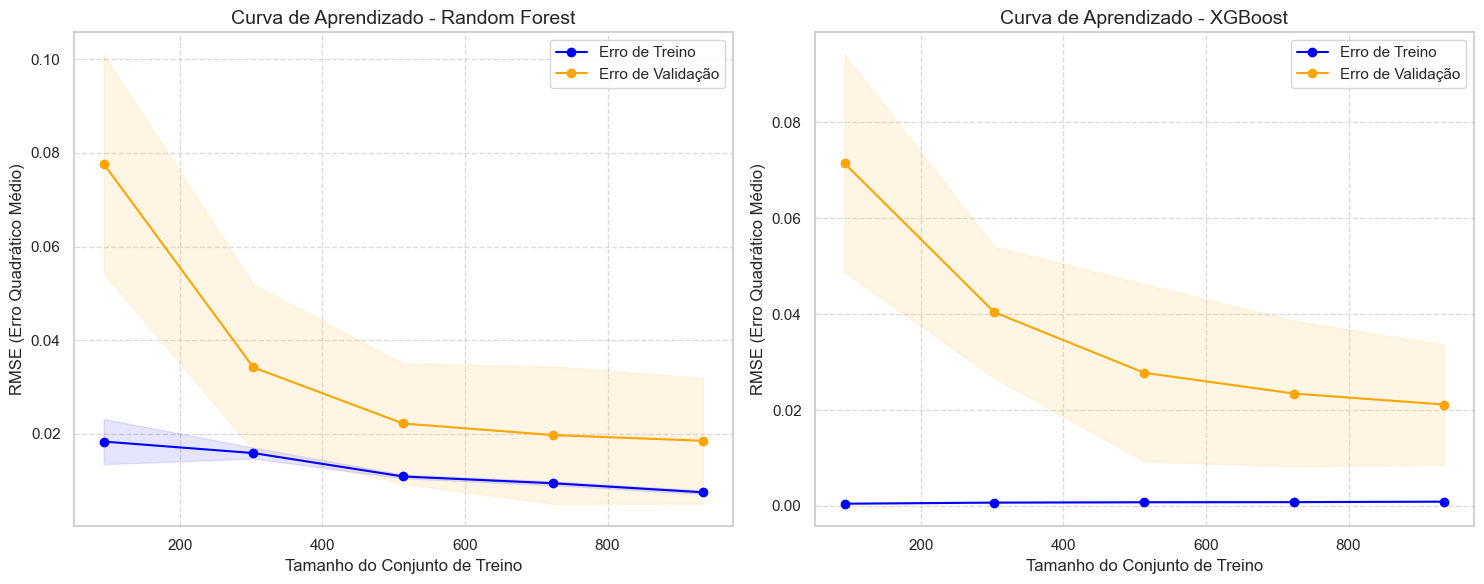

In [49]:
#Será que deu overfitting ?
# Pega todas as colunas numéricas (int, float)
cols_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Pega todas as colunas de texto/categóricas (object)
cols_categoricas = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Configurando o pré-processador

preprocessor = ColumnTransformer(
    transformers=[
        # Para números: preenche valores nulos com a mediana
        ('num', SimpleImputer(strategy='median'), cols_numericas),
        
        # Para categorias preenche nulos com o mais frequente e aplica o OneHotEncoder
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cols_categoricas)
    ])

# 3. Criacão dos modelos dentro de pipelines
# O pré-processador é executado antes do modelo em cada etapa da validação cruzada
modelos = {
    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    'XGBoost': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ])
}

# 4. Plot das curvas
# Cria a figura para plotar (1 linha, 2 colunas)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (nome, modelo_pipeline) in zip(axes, modelos.items()):
    print(f"Calculando curva de aprendizado para: {nome}...")
    
    # Executa a função learning_curve usando o pipeline completo
    train_sizes, train_scores, val_scores = learning_curve(
        modelo_pipeline, X, Y, 
        cv=5, 
        scoring='neg_root_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 5), 
        n_jobs=-1 # Usa todos os núcleos do processador
    )
    
    # Como o scikit-learn retorna scores negativos para erros é invertido
    train_scores_mean = -np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    val_scores_mean = -np.mean(val_scores, axis=1)
    val_scores_std = np.std(val_scores, axis=1)
    
    # Configuração do gráfico
    ax.set_title(f"Curva de Aprendizado - {nome}", fontsize=14)
    ax.set_xlabel("Tamanho do Conjunto de Treino", fontsize=12)
    ax.set_ylabel("RMSE (Erro Quadrático Médio)", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Plota a área de desvio padrão para sombrear
    ax.fill_between(train_sizes, train_scores_mean - train_scores_std,train_scores_mean + train_scores_std, alpha=0.1, color="blue")
    ax.fill_between(train_sizes, val_scores_mean - val_scores_std, val_scores_mean + val_scores_std, alpha=0.1, color="orange")
    
    # Plota as linhas médias
    ax.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Erro de Treino")
    ax.plot(train_sizes, val_scores_mean, 'o-', color="orange", label="Erro de Validação")
    
    ax.legend(loc="best")

plt.tight_layout()
plt.show()